# **Employee Attrition Prediction**

## Predicting Employee Attrition Using Machine Learning

### 📌 Project Overview

Employee attrition is one of the major challenges faced by organizations because losing valuable employees increases recruitment costs, decreases productivity, and affects organizational performance.

This project aims to build a machine learning model capable of predicting whether an employee is likely to leave the company based on demographic information, job characteristics, compensation, and work-related factors.

The project follows an end-to-end machine learning workflow, including data preprocessing, feature engineering, model development, model evaluation, and business recommendations.

---

**Author:** Tiara Azahra Wika Putri

# 1️⃣ I**mport Libraries**

The following libraries are used for data manipulation, visualization, preprocessing, machine learning, and model evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score
)

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

# 2️⃣ **Load Dataset**

The IBM HR Analytics dataset is loaded into a Pandas DataFrame for machine learning analysis.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving data_IBM.csv to data_IBM.csv


In [3]:
df = pd.read_csv("data_IBM.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# 3️⃣ **Data Understanding**

Before building the predictive model, we examine the dataset structure, feature types, missing values, duplicate records, and target variable distribution.

In [4]:
df.shape

(1470, 35)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [7]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


# 4️⃣ **Data Cleaning**

Before training the machine learning models, the dataset is cleaned by removing irrelevant features and checking for data quality issues.

The following preprocessing steps are performed:

- Remove identifier columns
- Remove constant-value columns
- Verify missing values
- Verify duplicate records

In [4]:
df.drop("EmployeeNumber", axis=1, inplace=True)

In [5]:
df.drop(
    columns=[
        "EmployeeCount",
        "StandardHours",
        "Over18"
    ],
    inplace=True
)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

# 5️⃣ **Feature Engineering**

Several new features are created to improve model interpretability and business analysis.

## Income Level

Employees are categorized into three income groups using quantile-based segmentation.

In [7]:
df["IncomeLevel"] = pd.qcut(
    df["MonthlyIncome"],
    q=3,
    labels=["Low","Medium","High"]
)

## Age Group

Employees are grouped according to their age.

In [8]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[18,30,40,50,60],
    labels=[
        "18-30",
        "31-40",
        "41-50",
        "51-60"
    ],
    include_lowest=True
)

## Tenure Group

Employees are grouped based on their years at the company.

In [9]:
df["TenureGroup"] = pd.cut(
    df["YearsAtCompany"],
    bins=[-1,5,10,20,40],
    labels=[
        "0-5 Years",
        "6-10 Years",
        "11-20 Years",
        ">20 Years"
    ]
)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Age                       1470 non-null   int64   
 1   Attrition                 1470 non-null   object  
 2   BusinessTravel            1470 non-null   object  
 3   DailyRate                 1470 non-null   int64   
 4   Department                1470 non-null   object  
 5   DistanceFromHome          1470 non-null   int64   
 6   Education                 1470 non-null   int64   
 7   EducationField            1470 non-null   object  
 8   EnvironmentSatisfaction   1470 non-null   int64   
 9   Gender                    1470 non-null   object  
 10  HourlyRate                1470 non-null   int64   
 11  JobInvolvement            1470 non-null   int64   
 12  JobLevel                  1470 non-null   int64   
 13  JobRole                   1470 non-null   object

# 6️⃣ **Data Preprocessing**

Machine learning algorithms require numerical input. Therefore, categorical variables are encoded before model training.

In [11]:
df["Attrition"] = df["Attrition"].map({
    "No":0,
    "Yes":1
})

In [12]:
categorical_columns = df.select_dtypes(
    include=["object","category"]
).columns

categorical_columns

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime', 'IncomeLevel', 'AgeGroup', 'TenureGroup'],
      dtype='object')

In [13]:
le = LabelEncoder()

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   int64
 2   BusinessTravel            1470 non-null   int64
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   int64
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   int64
 8   EnvironmentSatisfaction   1470 non-null   int64
 9   Gender                    1470 non-null   int64
 10  HourlyRate                1470 non-null   int64
 11  JobInvolvement            1470 non-null   int64
 12  JobLevel                  1470 non-null   int64
 13  JobRole                   1470 non-null   int64
 14  JobSatisfaction           1470 non-null 

# 7️⃣ **Feature Selection**

Separate predictor variables (X) from the target variable (y).

In [15]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

# 8️⃣ **Train-Test Split**

The dataset is divided into training data (80%) and testing data (20%).

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
print("Training :", X_train.shape)
print("Testing  :", X_test.shape)

Training : (1176, 33)
Testing  : (294, 33)


# 9️⃣ **Random Forest Classifier**

Random Forest is used as the baseline classification model because it is robust, easy to interpret, and performs well on tabular datasets.

In [24]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [25]:
rf_pred = rf_model.predict(X_test)

In [26]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Accuracy : 0.8367346938775511
Precision: 0.45454545454545453
Recall   : 0.10638297872340426
F1 Score : 0.1724137931034483


In [27]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.45      0.11      0.17        47

    accuracy                           0.84       294
   macro avg       0.65      0.54      0.54       294
weighted avg       0.79      0.84      0.79       294



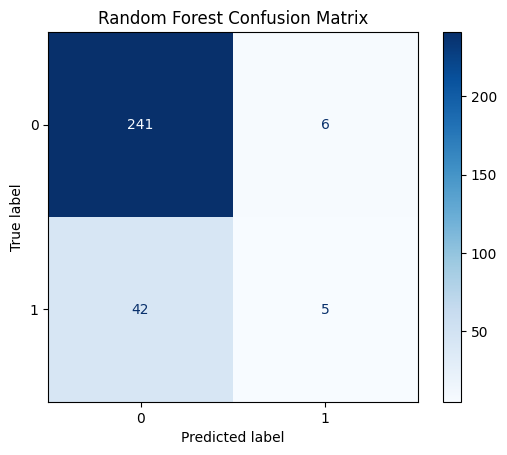

In [28]:
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

#**10. XGBoost Classifier**

XGBoost is a gradient boosting algorithm widely used for structured/tabular datasets because of its strong predictive performance.

In [29]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [30]:
xgb_pred = xgb_model.predict(X_test)

In [31]:
print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))

Accuracy : 0.8605442176870748
Precision: 0.625
Recall   : 0.3191489361702128
F1 Score : 0.4225352112676056


In [32]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.32      0.42        47

    accuracy                           0.86       294
   macro avg       0.75      0.64      0.67       294
weighted avg       0.84      0.86      0.84       294



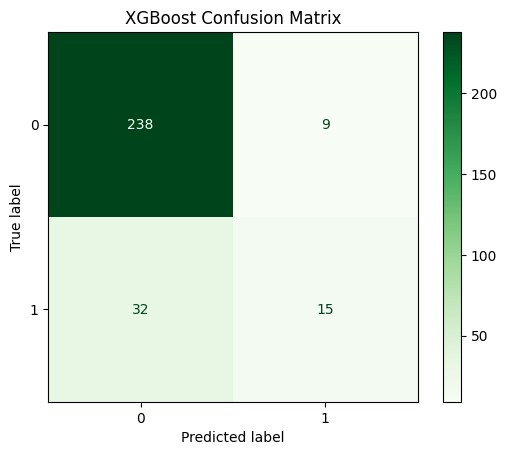

In [33]:
ConfusionMatrixDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test,
    cmap="Greens"
)

plt.title("XGBoost Confusion Matrix")
plt.show()

# **11. Model Performance Comparison**

The performance of Random Forest and XGBoost is compared using Accuracy, Precision, Recall, and F1-Score.

In [34]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.836735,0.454545,0.106383,0.172414
1,XGBoost,0.860544,0.625000,0.319149,0.422535


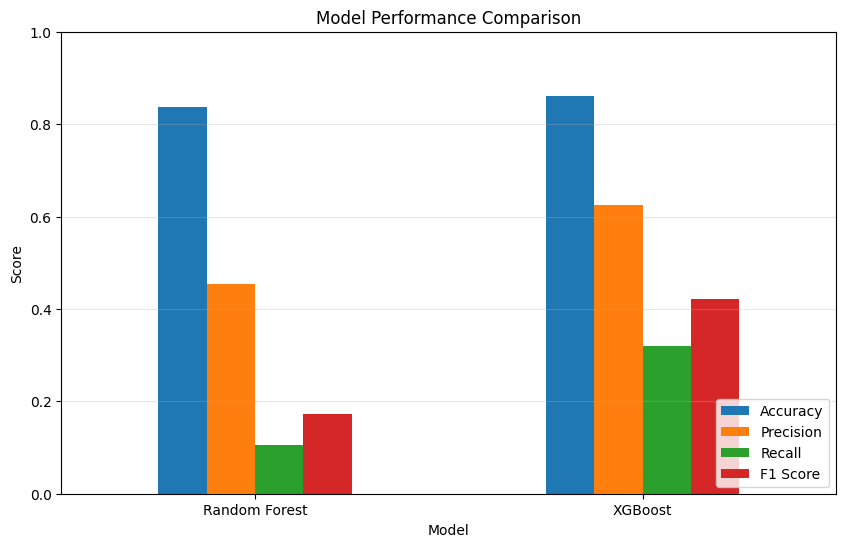

In [35]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.legend(loc="lower right")

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.show()

#**12. Feature Importance**

Feature importance helps identify which variables contribute the most to predicting employee attrition. These insights can guide HR managers in prioritizing retention strategies.

In [36]:
# Feature Importance - Random Forest

rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_importance.head(15)

,Feature,Importance
15,MonthlyIncome,0.073853
0,Age,0.058680
23,TotalWorkingYears,0.057255
2,DailyRate,0.054925
16,MonthlyRate,0.049377
9,HourlyRate,0.047108
4,DistanceFromHome,0.046397
26,YearsAtCompany,0.045396
18,OverTime,0.040918
17,NumCompaniesWorked,0.037786


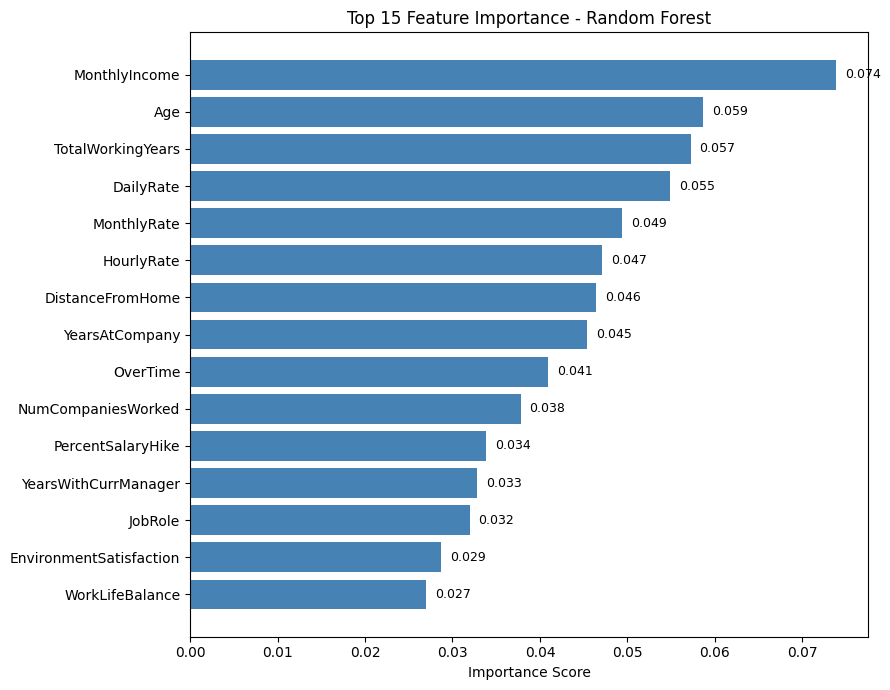

In [37]:
plt.figure(figsize=(9,7))

plt.barh(
    rf_importance["Feature"][:15][::-1],
    rf_importance["Importance"][:15][::-1],
    color="steelblue"
)

plt.title("Top 15 Feature Importance - Random Forest")
plt.xlabel("Importance Score")

# Tambahkan angka pada bar
for i, value in enumerate(rf_importance["Importance"][:15][::-1]):
    plt.text(
        value + 0.001,
        i,
        f"{value:.3f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [38]:
# Feature Importance - XGBoost

xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

xgb_importance.head(15)

,Feature,Importance
23,TotalWorkingYears,0.074884
18,OverTime,0.067698
14,MaritalStatus,0.054230
22,StockOptionLevel,0.053834
11,JobLevel,0.047820
7,EnvironmentSatisfaction,0.043990
29,YearsWithCurrManager,0.042947
0,Age,0.040485
10,JobInvolvement,0.038484
12,JobRole,0.037039


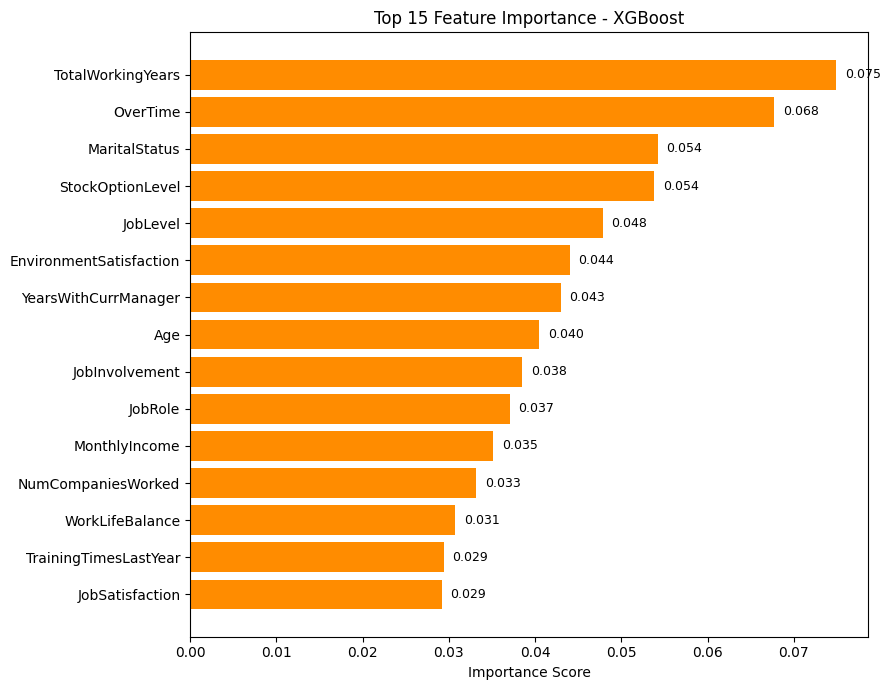

In [39]:
plt.figure(figsize=(9,7))

plt.barh(
    xgb_importance["Feature"][:15][::-1],
    xgb_importance["Importance"][:15][::-1],
    color="darkorange"
)

plt.title("Top 15 Feature Importance - XGBoost")
plt.xlabel("Importance Score")

# Tambahkan angka pada bar
for i, value in enumerate(xgb_importance["Importance"][:15][::-1]):
    plt.text(
        value + 0.001,
        i,
        f"{value:.3f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# **13.  ROC Curve**

The ROC Curve evaluates the classification performance across different decision thresholds. A higher AUC indicates better discrimination between employees who leave and those who stay.

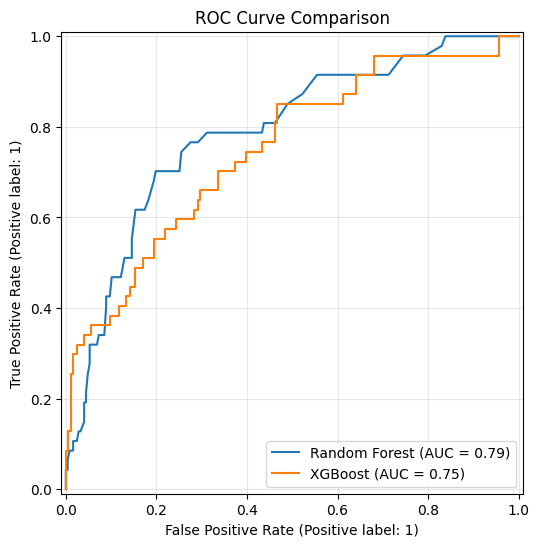

In [40]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8,6))

RocCurveDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    name="Random Forest",
    ax=plt.gca()
)

RocCurveDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test,
    name="XGBoost",
    ax=plt.gca()
)

plt.title("ROC Curve Comparison")
plt.grid(alpha=0.3)

plt.show()

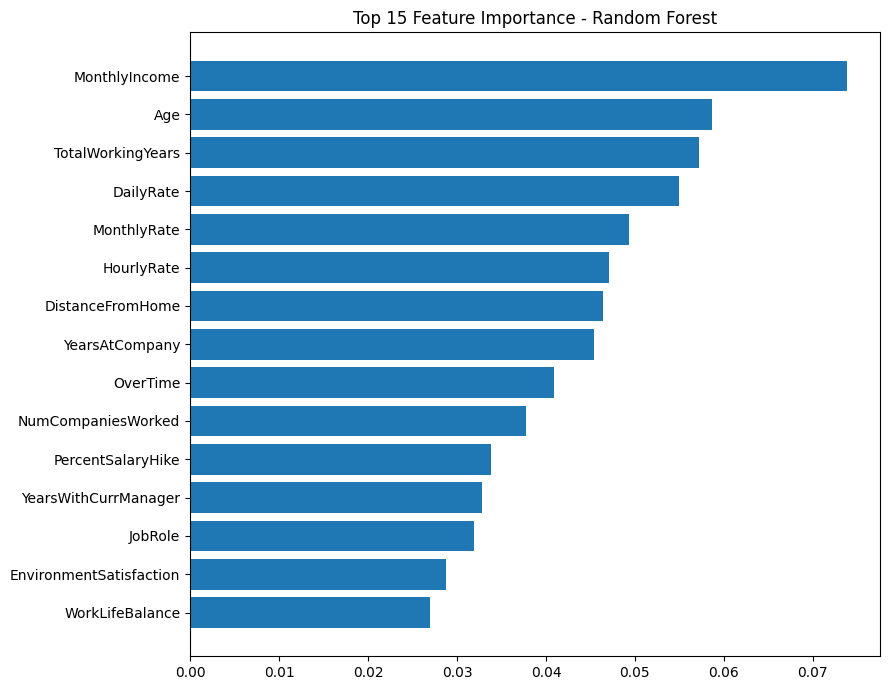

In [41]:
plt.figure(figsize=(9,7))

plt.barh(
    rf_importance["Feature"][:15][::-1],
    rf_importance["Importance"][:15][::-1]
)

plt.title("Top 15 Feature Importance - Random Forest")
plt.tight_layout()

plt.savefig(
    "Feature_Importance_RF.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

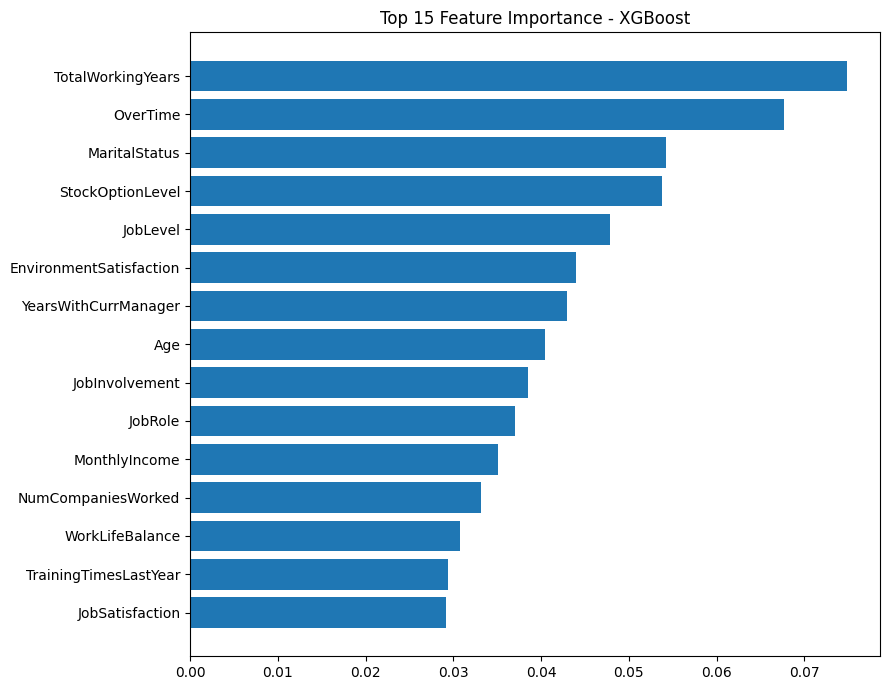

In [42]:
plt.figure(figsize=(9,7))

plt.barh(
    xgb_importance["Feature"][:15][::-1],
    xgb_importance["Importance"][:15][::-1]
)

plt.title("Top 15 Feature Importance - XGBoost")
plt.tight_layout()

plt.savefig(
    "Feature_Importance_XGBoost.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

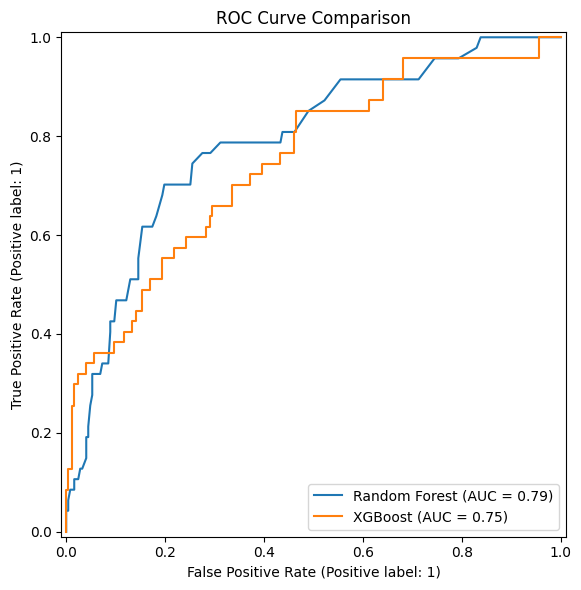

In [43]:
plt.figure(figsize=(8,6))

RocCurveDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    name="Random Forest",
    ax=plt.gca()
)

RocCurveDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test,
    name="XGBoost",
    ax=plt.gca()
)

plt.title("ROC Curve Comparison")

plt.tight_layout()

plt.savefig(
    "ROC_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# **15. Business Insights**

The exploratory analysis and predictive modeling reveal several important factors associated with employee attrition. These insights can support HR decision-making by identifying high-risk employee groups and areas where retention strategies should be prioritized.

### 📌 Insight 1 — Overall Attrition

Approximately **16.12%** of employees have left the company.

Although most employees remain with the company, this attrition rate indicates a meaningful level of employee turnover that may increase recruitment costs and reduce organizational productivity.

### 📌 Insight 2 — Department

The Sales department shows the highest attrition rate among all departments.

This suggests that employees in customer-facing roles may experience higher workloads, performance pressure, or job stress compared with other departments.

### 📌 Insight 3 — Overtime

Employees who work overtime have a significantly higher attrition rate than those who do not.

This finding indicates that excessive workload and long working hours are strong indicators of employee turnover.

### 📌 Insight 4 — Job Role

Several job roles experience noticeably higher attrition rates than others.

These positions should become the primary focus of HR retention programs, career development initiatives, and employee engagement strategies.

### 📌 Insight 5 — Age

Younger employees tend to leave the organization more frequently than older employees.

This pattern suggests that early-career employees may have greater career mobility and are more likely to seek alternative opportunities.

### 📌 Insight 6 — Income

Employees within the lower income group exhibit higher attrition rates.

Competitive compensation and clear career progression may help improve employee retention.

### 📌 Insight 7 — Years at Company

Employees with shorter tenure are more likely to resign.

This suggests that onboarding quality and employee experience during the first few years are critical for long-term retention.

#**16. Machine Learning Insights**

The predictive models demonstrate that machine learning can effectively identify employees who are at risk of leaving the organization.

Among the evaluated models, **XGBoost outperformed Random Forest** across all evaluation metrics, making it the preferred model for employee attrition prediction.

### Model Comparison

|Model|Accuracy|Precision|Recall|F1|
|------|-------:|--------:|------:|------:|
|Random Forest|83.67%|45.45%|10.64%|17.24%|
|XGBoost|86.05%|62.50%|31.91%|42.25%|

#**17. Business Recommendations**

### Recommendation 1

Reduce excessive overtime by improving workload distribution and workforce planning.

### Recommendation 2

Provide additional support for employees during their first five years through mentoring and structured onboarding programs.

### Recommendation 3

Review compensation policies for lower-income employees to improve competitiveness and reduce voluntary turnover.

### Recommendation 4

Develop career progression plans for high-risk job roles identified in the analysis.

### Recommendation 5

Deploy the XGBoost model as an early warning system to proactively identify employees at high risk of attrition.

#**18. Conclusion**

This project demonstrates how Exploratory Data Analysis (EDA) and Machine Learning can support HR decision-making by identifying employee attrition patterns and predicting future turnover.

The analysis highlights that overtime, compensation, tenure, age, and job role are among the most influential factors associated with employee attrition.

Among the evaluated models, XGBoost achieved the best overall performance and can serve as a practical tool for proactive employee retention strategies.

#**19. Handling Imbalanced Dataset using SMOTE**

The original dataset is imbalanced, where employees who leave the company represent only about 16% of the observations. To improve the model's ability to detect employee attrition, Synthetic Minority Oversampling Technique (SMOTE) is applied only to the training data.

# **20. Find the best parameters**

In [87]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {

    "n_estimators":[100,200,300],

    "max_depth":[3,4,5,6],

    "learning_rate":[0.01,0.05,0.1],

    "subsample":[0.8,0.9,1],

    "colsample_bytree":[0.8,0.9,1]

}

search = RandomizedSearchCV(

    estimator=XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ),

    param_distributions=param_grid,

    n_iter=20,

    scoring="f1",

    cv=5,

    random_state=42,

    n_jobs=-1

)

search.fit(X_train_smote, y_train_smote)

print(search.best_params_)

{'subsample': 1, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.9}


# **21. Comparison of 6 Models**

In [16]:
import time
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [17]:
best_params = {
    "n_estimators": 300,
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 1,
    "colsample_bytree": 0.9
}

In [18]:
sss = StratifiedShuffleSplit(
    n_splits=50,
    test_size=0.2,
    random_state=None
)

results = []

for i, (train_idx, test_idx) in enumerate(sss.split(X, y), start=1):

    print(f"Iteration {i}/50")

    # ==========================================================
    # Split Data
    # ==========================================================

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # ==========================================================
    # SMOTE
    # ==========================================================

    smote = SMOTE(random_state=42)

    X_train_smote, y_train_smote = smote.fit_resample(
        X_train,
        y_train
    )

    # ==========================================================
    # Semua Model
    # ==========================================================

    models = {

        "Random Forest":
        (
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            ),
            X_train,
            y_train
        ),

        "XGBoost":
        (
            XGBClassifier(
                eval_metric="logloss",
                random_state=42
            ),
            X_train,
            y_train
        ),

        "Random Forest + SMOTE":
        (
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            ),
            X_train_smote,
            y_train_smote
        ),

        "XGBoost + SMOTE":
        (
            XGBClassifier(
                eval_metric="logloss",
                random_state=42
            ),
            X_train_smote,
            y_train_smote
        ),

        "Tuned XGBoost":
        (
            XGBClassifier(
                **best_params,
                eval_metric="logloss",
                random_state=42
            ),
            X_train,
            y_train
        ),

        "Tuned XGBoost + SMOTE":
        (
            XGBClassifier(
                **best_params,
                eval_metric="logloss",
                random_state=42
            ),
            X_train_smote,
            y_train_smote
        )
    }

    # ==========================================================
    # Training Semua Model
    # ==========================================================

    for model_name, (model, Xtr, ytr) in models.items():

        train_start = time.time()

        model.fit(Xtr, ytr)

        train_end = time.time()

        pred_start = time.time()

        pred = model.predict(X_test)

        pred_end = time.time()

        results.append({

            "Iteration": i,

            "Model": model_name,

            "Train Size": len(Xtr),

            "Test Size": len(X_test),

            "Class 0 Before": (y_train==0).sum(),

            "Class 1 Before": (y_train==1).sum(),

            "Class 0 After": (ytr==0).sum(),

            "Class 1 After": (ytr==1).sum(),

            "Accuracy": accuracy_score(y_test,pred),

            "Precision": precision_score(y_test,pred),

            "Recall": recall_score(y_test,pred),

            "F1 Score": f1_score(y_test,pred),

            "Training Time (s)": train_end-train_start,

            "Prediction Time (s)": pred_end-pred_start

        })

results = pd.DataFrame(results)

results.head()

Iteration 1/50
Iteration 2/50
Iteration 3/50
Iteration 4/50
Iteration 5/50
Iteration 6/50
Iteration 7/50
Iteration 8/50
Iteration 9/50
Iteration 10/50
Iteration 11/50
Iteration 12/50
Iteration 13/50
Iteration 14/50
Iteration 15/50
Iteration 16/50
Iteration 17/50
Iteration 18/50
Iteration 19/50
Iteration 20/50
Iteration 21/50
Iteration 22/50
Iteration 23/50
Iteration 24/50
Iteration 25/50
Iteration 26/50
Iteration 27/50
Iteration 28/50
Iteration 29/50
Iteration 30/50
Iteration 31/50
Iteration 32/50
Iteration 33/50
Iteration 34/50
Iteration 35/50
Iteration 36/50
Iteration 37/50
Iteration 38/50
Iteration 39/50
Iteration 40/50
Iteration 41/50
Iteration 42/50
Iteration 43/50
Iteration 44/50
Iteration 45/50
Iteration 46/50
Iteration 47/50
Iteration 48/50
Iteration 49/50
Iteration 50/50


,Iteration,Model,Train Size,Test Size,Class 0 Before,Class 1 Before,Class 0 After,Class 1 After,Accuracy,Precision,Recall,F1 Score,Training Time (s),Prediction Time (s)
0,1,Random Forest,1176,294,986,190,986,190,0.853741,0.642857,0.191489,0.295082,0.784151,0.027920
1,1,XGBoost,1176,294,986,190,986,190,0.843537,0.516129,0.340426,0.410256,0.484365,0.011682
2,1,Random Forest + SMOTE,1972,294,986,190,986,986,0.826531,0.458333,0.468085,0.463158,1.058476,0.027493
3,1,XGBoost + SMOTE,1972,294,986,190,986,986,0.843537,0.511628,0.468085,0.488889,0.252578,0.026552
4,1,Tuned XGBoost,1176,294,986,190,986,190,0.850340,0.555556,0.319149,0.405405,0.707566,0.009216


In [19]:
summary = results.groupby("Model").agg({

    "Accuracy":["mean","std"],

    "Precision":["mean","std"],

    "Recall":["mean","std"],

    "F1 Score":["mean","std"],

    "Training Time (s)":["mean","std"],

    "Prediction Time (s)":["mean","std"]

}).round(4)

summary

Accuracy         Precision          Recall          \
                          mean     std      mean     std    mean     std   
Model                                                                      
Random Forest           0.8590  0.0110    0.7664  0.1629  0.1668  0.0602   
Random Forest + SMOTE   0.8393  0.0158    0.4989  0.0743  0.3285  0.0691   
Tuned XGBoost           0.8640  0.0133    0.6803  0.0984  0.2851  0.0660   
Tuned XGBoost + SMOTE   0.8424  0.0152    0.5097  0.0663  0.3826  0.0761   
XGBoost                 0.8631  0.0137    0.6530  0.0937  0.3174  0.0612   
XGBoost + SMOTE         0.8418  0.0191    0.5097  0.0800  0.3902  0.0748   

                      F1 Score         Training Time (s)          \
                          mean     std              mean     std   
Model                                                              
Random Forest           0.2705  0.0872            0.5616  0.1579   
Random Forest + SMOTE   0.3932  0.0647            0.7446  0.2163   
Tuned XGBoost           0.3984  0.0755            0.3210  0.2756   
Tuned XGBoost + SMOTE   0.4344  0.0669            0.3973  0.3029   
XGBoost                 0.4237  0.0664            0.1075  0.1003   
XGBoost + SMOTE         0.4393  0.0697            0.1801  0.3902   

                      Prediction Time (s)          
                                     mean     std  
Model                                              
Random Forest                      0.0180  0.0033  
Random Forest + SMOTE              0.0206  0.0064  
Tuned XGBoost                      0.0072  0.0026  
Tuned XGBoost + SMOTE              0.0084  0.0064  
XGBoost                            0.0070  0.0031  
XGBoost + SMOTE                    0.0068  0.0050

In [20]:
comparison = results.groupby("Model")[

    ["Accuracy",
     "Precision",
     "Recall",
     "F1 Score"]

].mean().round(4)

comparison

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Random Forest,0.8590,0.7664,0.1668,0.2705
Random Forest + SMOTE,0.8393,0.4989,0.3285,0.3932
Tuned XGBoost,0.8640,0.6803,0.2851,0.3984
Tuned XGBoost + SMOTE,0.8424,0.5097,0.3826,0.4344
XGBoost,0.8631,0.6530,0.3174,0.4237
XGBoost + SMOTE,0.8418,0.5097,0.3902,0.4393


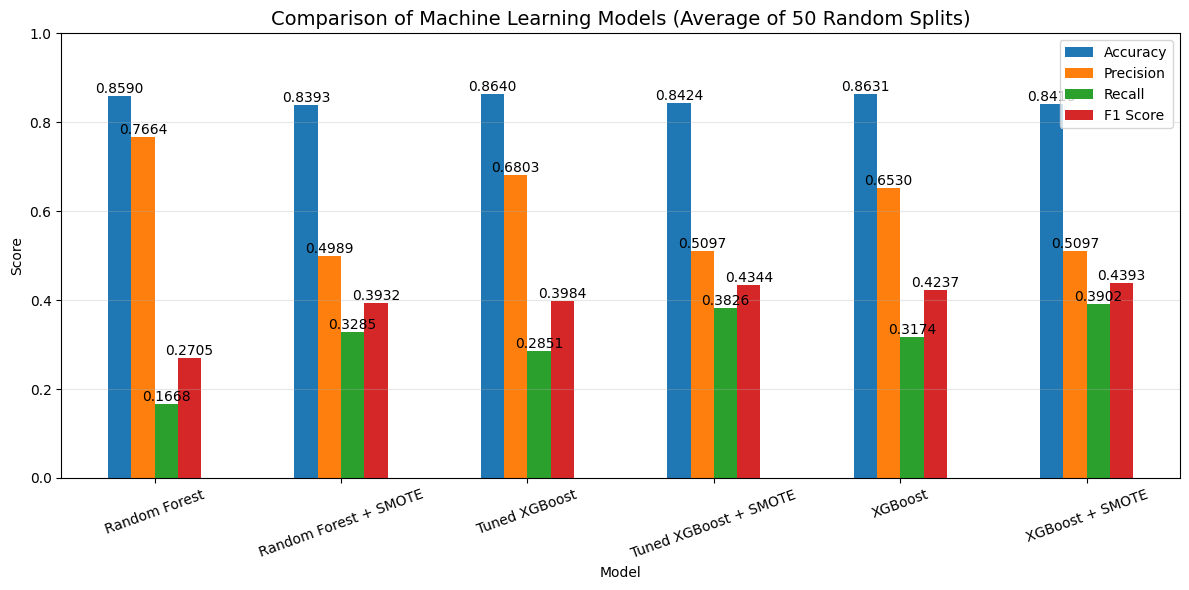

In [33]:
ax = comparison.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title(
    "Comparison of Machine Learning Models (Average of 50 Random Splits)",
    fontsize=14
)

plt.ylabel("Score")

plt.xlabel("Model")

plt.xticks(rotation=20)

plt.ylim(0,1)

plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f")

plt.tight_layout()

plt.show()

In [22]:
with pd.ExcelWriter(
    "HR_Model_Comparison_50_Iterations.xlsx",
    engine="openpyxl"
) as writer:

    results.to_excel(
        writer,
        sheet_name="All Results",
        index=False
    )

    summary.to_excel(
        writer,
        sheet_name="Summary"
    )

    comparison.to_excel(
        writer,
        sheet_name="Average Comparison"
    )

print("Excel berhasil disimpan.")

Excel berhasil disimpan.


In [23]:
from google.colab import files

files.download(
    "HR_Model_Comparison_50_Iterations.xlsx"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#**22. 6 Models+ROC**

In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

import numpy as np

In [27]:
sss = StratifiedShuffleSplit(
    n_splits=50,
    test_size=0.2,
    random_state=None
)

results = []

confusion_results = []

roc_results = []

for i, (train_idx, test_idx) in enumerate(sss.split(X, y), start=1):

    print(f"Iteration {i}/50")

    # ==========================================================
    # Split Data
    # ==========================================================

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # ==========================================================
    # SMOTE
    # ==========================================================

    smote = SMOTE(random_state=42)

    X_train_smote, y_train_smote = smote.fit_resample(
        X_train,
        y_train
    )

    # ==========================================================
    # Semua Model
    # ==========================================================

    models = {

        "Random Forest":
        (
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            ),
            X_train,
            y_train
        ),

        "XGBoost":
        (
            XGBClassifier(
                eval_metric="logloss",
                random_state=42
            ),
            X_train,
            y_train
        ),

        "Random Forest + SMOTE":
        (
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            ),
            X_train_smote,
            y_train_smote
        ),

        "XGBoost + SMOTE":
        (
            XGBClassifier(
                eval_metric="logloss",
                random_state=42
            ),
            X_train_smote,
            y_train_smote
        ),

        "Tuned XGBoost":
        (
            XGBClassifier(
                **best_params,
                eval_metric="logloss",
                random_state=42
            ),
            X_train,
            y_train
        ),

        "Tuned XGBoost + SMOTE":
        (
            XGBClassifier(
                **best_params,
                eval_metric="logloss",
                random_state=42
            ),
            X_train_smote,
            y_train_smote
        )
    }

    # ==========================================================
    # Training Semua Model
    # ==========================================================

    for model_name, (model, Xtr, ytr) in models.items():

        train_start = time.time()

        model.fit(Xtr, ytr)

        train_end = time.time()

        pred_start = time.time()

        pred = model.predict(X_test)
        prob = model.predict_proba(X_test)[:,1]

        pred_end = time.time()

        cm = confusion_matrix(y_test, pred)

        tn, fp, fn, tp = cm.ravel()

        results.append({

            "Iteration": i,

            "Model": model_name,

            "Accuracy": accuracy_score(y_test,pred),

            "Precision": precision_score(y_test,pred),

            "Recall": recall_score(y_test,pred),

            "F1 Score": f1_score(y_test,pred),

            "ROC AUC": roc_auc_score(y_test,prob),

            "Training Time (s)": train_end-train_start,

            "Prediction Time (s)": pred_end-pred_start

        })

        confusion_results.append({

            "Iteration": i,

            "Model": model_name,

            "TN": tn,

            "FP": fp,

            "FN": fn,

            "TP": tp

        })

results = pd.DataFrame(results)

confusion_results = pd.DataFrame(confusion_results)

results.head()

Iteration 1/50
Iteration 2/50
Iteration 3/50
Iteration 4/50
Iteration 5/50
Iteration 6/50
Iteration 7/50
Iteration 8/50
Iteration 9/50
Iteration 10/50
Iteration 11/50
Iteration 12/50
Iteration 13/50
Iteration 14/50
Iteration 15/50
Iteration 16/50
Iteration 17/50
Iteration 18/50
Iteration 19/50
Iteration 20/50
Iteration 21/50
Iteration 22/50
Iteration 23/50
Iteration 24/50
Iteration 25/50
Iteration 26/50
Iteration 27/50
Iteration 28/50
Iteration 29/50
Iteration 30/50
Iteration 31/50
Iteration 32/50
Iteration 33/50
Iteration 34/50
Iteration 35/50
Iteration 36/50
Iteration 37/50
Iteration 38/50
Iteration 39/50
Iteration 40/50
Iteration 41/50
Iteration 42/50
Iteration 43/50
Iteration 44/50
Iteration 45/50
Iteration 46/50
Iteration 47/50
Iteration 48/50
Iteration 49/50
Iteration 50/50


,Iteration,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time (s),Prediction Time (s)
0,1,Random Forest,0.863946,0.888889,0.170213,0.285714,0.839306,0.497380,0.032890
1,1,XGBoost,0.874150,0.727273,0.340426,0.463768,0.791283,0.093376,0.010471
2,1,Random Forest + SMOTE,0.867347,0.633333,0.404255,0.493506,0.777457,0.675475,0.038569
3,1,XGBoost + SMOTE,0.853741,0.555556,0.425532,0.481928,0.796365,0.086001,0.010521
4,1,Tuned XGBoost,0.874150,0.777778,0.297872,0.430769,0.810406,0.238241,0.013324


In [28]:
summary = results.groupby("Model").agg({

    "Accuracy":["mean","std"],

    "Precision":["mean","std"],

    "Recall":["mean","std"],

    "F1 Score":["mean","std"],

    "ROC AUC":["mean","std"],

    "Training Time (s)":["mean"],

    "Prediction Time (s)":["mean"]

}).round(4)

summary

Accuracy         Precision          Recall          \
                          mean     std      mean     std    mean     std   
Model                                                                      
Random Forest           0.8571  0.0090    0.7735  0.1488  0.1562  0.0478   
Random Forest + SMOTE   0.8405  0.0140    0.5057  0.0709  0.3221  0.0574   
Tuned XGBoost           0.8653  0.0126    0.6977  0.1053  0.2877  0.0652   
Tuned XGBoost + SMOTE   0.8437  0.0155    0.5187  0.0667  0.3813  0.0653   
XGBoost                 0.8629  0.0118    0.6521  0.0861  0.3132  0.0593   
XGBoost + SMOTE         0.8412  0.0165    0.5092  0.0711  0.3851  0.0623   

                      F1 Score         ROC AUC         Training Time (s)  \
                          mean     std    mean     std              mean   
Model                                                                      
Random Forest           0.2562  0.0685  0.8076  0.0292            0.5124   
Random Forest + SMOTE   0.3910  0.0560  0.7595  0.0345            0.6987   
Tuned XGBoost           0.4028  0.0698  0.8006  0.0312            0.2516   
Tuned XGBoost + SMOTE   0.4366  0.0580  0.7738  0.0325            0.3193   
XGBoost                 0.4199  0.0630  0.7955  0.0297            0.1155   
XGBoost + SMOTE         0.4357  0.0556  0.7691  0.0334            0.1092   

                      Prediction Time (s)  
                                     mean  
Model                                      
Random Forest                      0.0406  
Random Forest + SMOTE              0.0377  
Tuned XGBoost                      0.0128  
Tuned XGBoost + SMOTE              0.0125  
XGBoost                            0.0118  
XGBoost + SMOTE                    0.0109

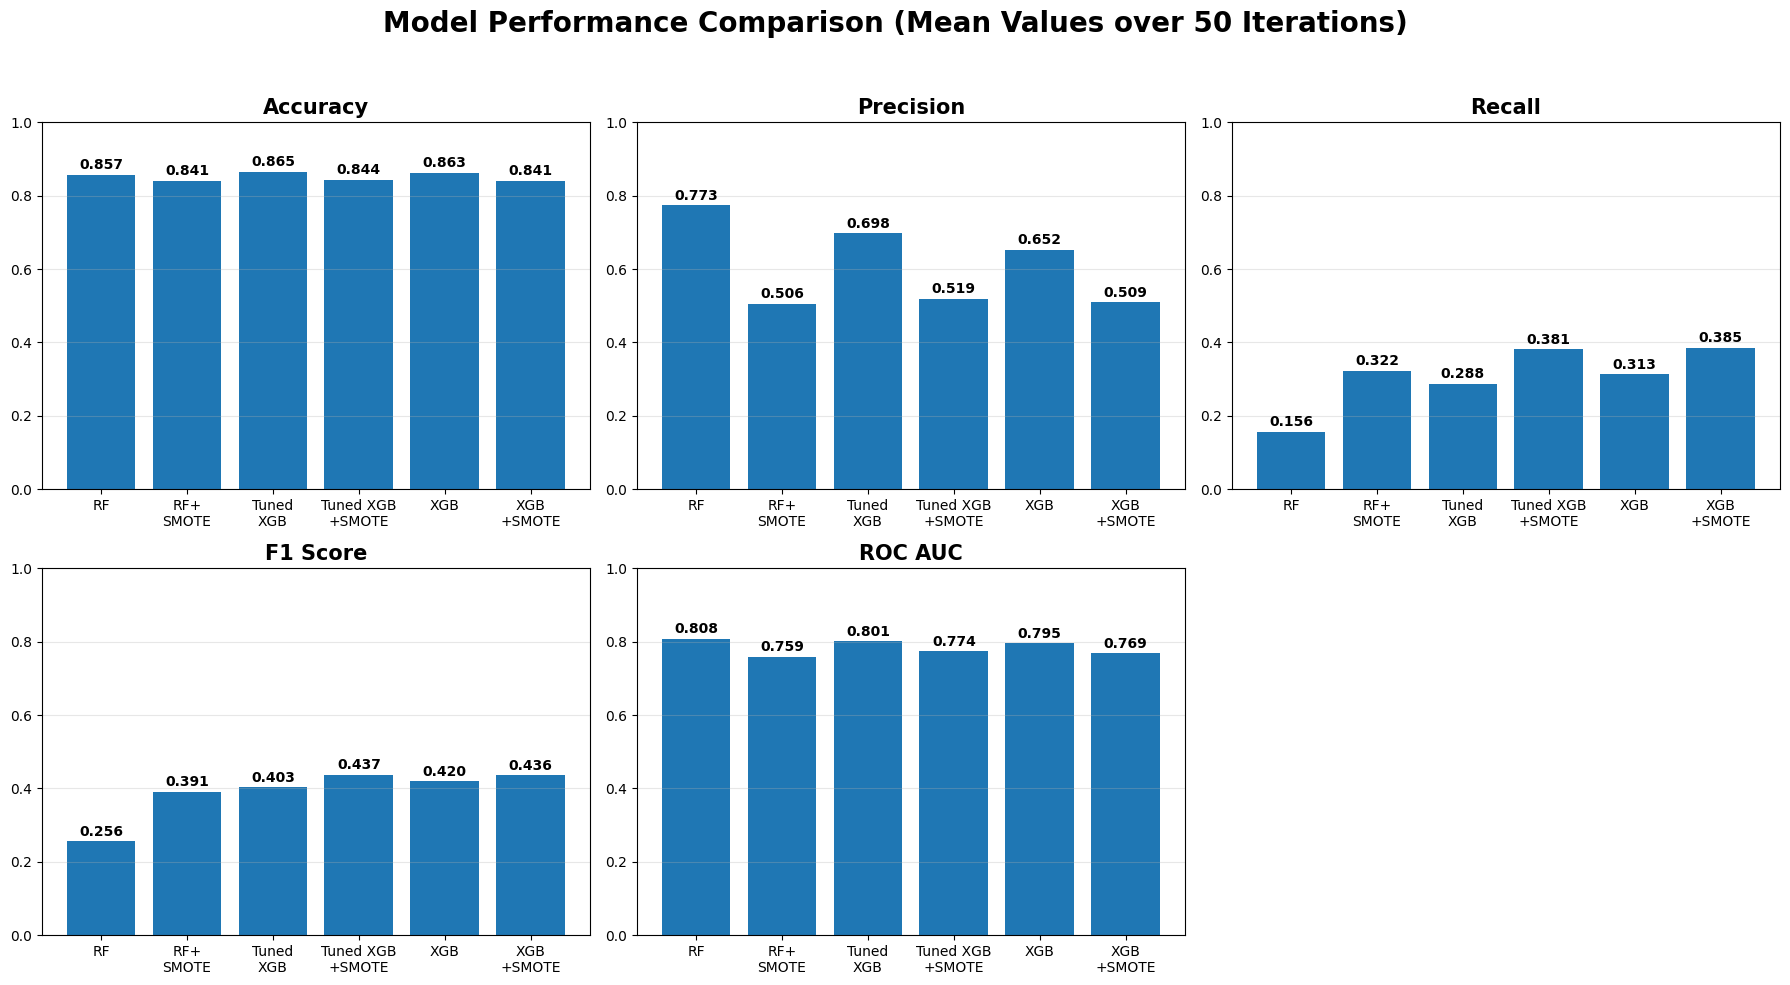

In [34]:
import matplotlib.pyplot as plt

# ==============================
# Mean values
# ==============================
models = [
    "RF",
    "RF+\nSMOTE",
    "Tuned\nXGB",
    "Tuned XGB\n+SMOTE",
    "XGB",
    "XGB\n+SMOTE"
]

accuracy = [0.8571, 0.8405, 0.8653, 0.8437, 0.8629, 0.8412]
precision = [0.7735, 0.5057, 0.6977, 0.5187, 0.6521, 0.5092]
recall = [0.1562, 0.3221, 0.2877, 0.3813, 0.3132, 0.3851]
f1 = [0.2562, 0.3910, 0.4028, 0.4366, 0.4199, 0.4357]
roc = [0.8076, 0.7595, 0.8006, 0.7738, 0.7955, 0.7691]

metrics = [
    ("Accuracy", accuracy),
    ("Precision", precision),
    ("Recall", recall),
    ("F1 Score", f1),
    ("ROC AUC", roc)
]

# ==============================
# Plot
# ==============================
fig, axes = plt.subplots(2, 3, figsize=(18,10))

axes = axes.flatten()

for i, (title, values) in enumerate(metrics):

    bars = axes[i].bar(models, values)

    axes[i].set_title(title,
                      fontsize=15,
                      fontweight='bold')

    axes[i].set_ylim(0,1)

    axes[i].grid(axis='y', alpha=0.3)

    for bar in bars:

        axes[i].text(
            bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.015,
            f"{bar.get_height():.3f}",
            ha='center',
            fontsize=10,
            fontweight='bold'
        )

# Hapus subplot terakhir (kosong)
fig.delaxes(axes[5])

plt.suptitle(
    "Model Performance Comparison (Mean Values over 50 Iterations)",
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout(rect=[0,0,1,0.95])

plt.savefig(
    "Model_Performance_Mean.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
cm_summary = confusion_results.groupby("Model").mean().round(2)

cm_summary

,Iteration,TN,FP,FN,TP
Model,,,,,
Random Forest,25.5,244.66,2.34,39.66,7.34
Random Forest + SMOTE,25.5,231.98,15.02,31.86,15.14
Tuned XGBoost,25.5,240.88,6.12,33.48,13.52
Tuned XGBoost + SMOTE,25.5,230.12,16.88,29.08,17.92
XGBoost,25.5,238.98,8.02,32.28,14.72
XGBoost + SMOTE,25.5,229.22,17.78,28.90,18.10


In [30]:
with pd.ExcelWriter(
    "HR_Model_Comparison_50_Iterations.xlsx",
    engine="openpyxl"
) as writer:

    results.to_excel(
        writer,
        sheet_name="All Results",
        index=False
    )

    summary.to_excel(
        writer,
        sheet_name="Summary"
    )

    comparison.to_excel(
        writer,
        sheet_name="Average Comparison"
    )

    confusion_results.to_excel(
        writer,
        sheet_name="Confusion Matrix",
        index=False
    )

    cm_summary.to_excel(
        writer,
        sheet_name="Average Confusion"
    )

print("Done")

Done


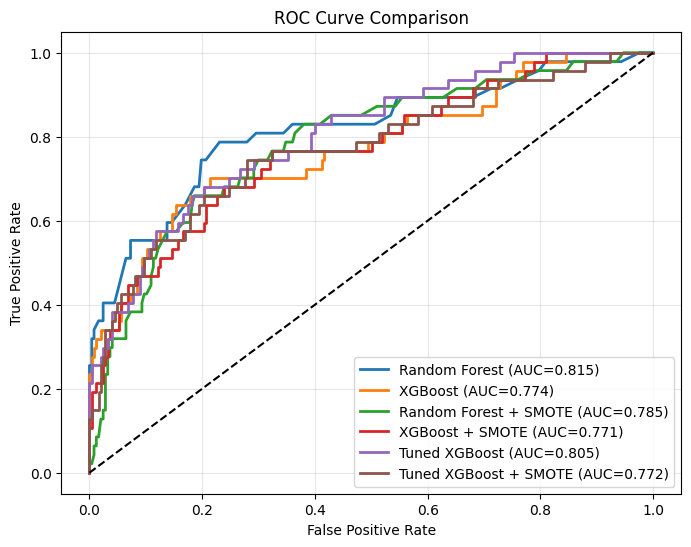

In [31]:
plt.figure(figsize=(8,6))

for model_name, (model, Xtr, ytr) in models.items():

    model.fit(Xtr, ytr)

    prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test,prob)

    auc = roc_auc_score(y_test,prob)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC={auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(alpha=.3)

plt.show()

#**23. The Feature Importance**

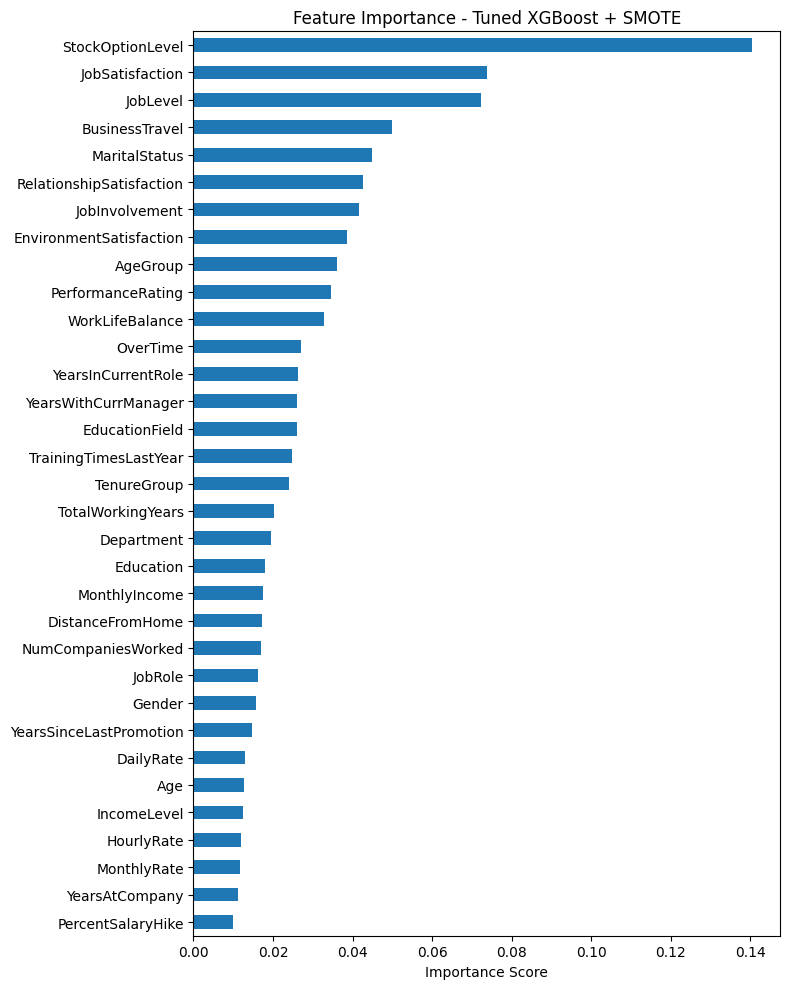

In [32]:
best_model = XGBClassifier(
    **best_params,
    eval_metric="logloss",
    random_state=42
)

best_model.fit(X_train_smote, y_train_smote)

importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8,10))

importance.plot(kind="barh")

plt.title("Feature Importance - Tuned XGBoost + SMOTE")

plt.xlabel("Importance Score")

plt.tight_layout()

plt.show()

---------------------------------

#**Executive Summary**

This HR Analytics project analyzes employee attrition using the IBM HR Analytics dataset to identify factors associated with employee turnover and evaluate machine learning models for predicting attrition risk.

The analysis combines exploratory data analysis, feature engineering, class imbalance handling using SMOTE, and predictive modeling with Random Forest and XGBoost. Model performance was evaluated using 50 stratified random train-test splits to ensure robust and reliable results.

Among the evaluated models, the tuned XGBoost with SMOTE achieved the strongest overall performance, demonstrating the benefit of hyperparameter optimization and class balancing for predicting employee attrition.

The insights generated from this analysis can help HR departments identify employees at higher risk of leaving and develop proactive retention strategies.

# **Business Insights**


##1. Overtime is the strongest indicator of employee attrition.



Employees who frequently work overtime exhibit a substantially higher attrition rate than employees who do not work overtime. This suggests that excessive workload and prolonged working hours may contribute to employee burnout and voluntary resignation.

Business Recommendation

Monitor overtime frequency.
Limit excessive overtime.
Review workload allocation.
Improve work-life balance initiatives.

##2. Sales Representatives and Laboratory Technicians experience the highest attrition.

Attrition varies considerably across job roles. Sales Representatives and Laboratory Technicians show noticeably higher turnover than managerial or research positions.

Business Recommendation

Review compensation packages.
Improve career development opportunities.
Conduct periodic engagement surveys.
Provide targeted retention programs.

##3. Younger employees are more likely to resign.

Employees aged below 30 demonstrate a higher attrition rate than older employees.

Possible reasons include:

Career exploration
Lower organizational commitment
Limited promotion opportunities
Competitive job market

Business Recommendation

Create structured onboarding.
Offer mentoring programs.
Establish transparent promotion pathways.
Provide clear career progression.

##4. Lower-income employees show higher turnover.

Employees within the lowest income category have a significantly higher likelihood of leaving the organization.

Compensation alone may not fully explain turnover but is likely an important contributing factor.

Business Recommendation

Review salary competitiveness.
Evaluate employee benefits.
Introduce performance-based incentives.
Improve recognition programs.

##5. Employees with short tenure are at greater risk.

Attrition is concentrated among employees with shorter years at the company.

This indicates that retaining employees during their early employment period is critical.

Business Recommendation

Strengthen onboarding.
Schedule regular one-on-one meetings.
Conduct early engagement assessments.
Improve first-year employee experience.

##6. Employee satisfaction remains an important factor.

Lower Job Satisfaction, Environment Satisfaction, and Work-Life Balance tend to coincide with higher attrition.

Business Recommendation

Increase employee engagement.
Improve workplace culture.
Expand flexible work policies where feasible.
Regularly monitor satisfaction indicators.

#**HR Recommendations**

| Priority | Recommendation                       | Expected Impact                           |
| -------- | ------------------------------------ | ----------------------------------------- |
| High     | Reduce excessive overtime            | Lower burnout and attrition               |
| High     | Focus on high-risk job roles         | Better employee retention                 |
| High     | Improve onboarding for new employees | Reduced early turnover                    |
| Medium   | Review compensation strategy         | Improved employee satisfaction            |
| Medium   | Enhance career development programs  | Increased long-term retention             |
| Medium   | Conduct periodic engagement surveys  | Earlier identification of attrition risks |


#**Machine Learning Insights**

Six predictive models were evaluated using 50 stratified random train-test splits.

The evaluation included:
1. Random Forest
2. XGBoost
3. Random Forest + SMOTE
4. XGBoost + SMOTE
5. Tuned XGBoost
6. Tuned XGBoost + SMOTE

Performance was assessed using:

1. Accuracy
2. Precision
3. Recall
4. F1 Score
5. ROC-AUC
6. Training Time
7. Prediction Time

Hyperparameter tuning and SMOTE improved the predictive capability of XGBoost, particularly in identifying employees who are likely to leave. This demonstrates the importance of addressing class imbalance and optimizing model parameters in employee attrition prediction tasks.

#**Final Conclusion**

The analysis indicates that employee attrition is primarily associated with overtime, compensation level, job role, employee age, and organizational tenure. These factors provide actionable insights for HR teams to design targeted retention initiatives.

From a machine learning perspective, the combination of SMOTE and hyperparameter-tuned XGBoost achieved the most robust predictive performance, making it a suitable candidate for supporting data-driven employee retention strategies.ay